In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv("apple_stock_20y.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["Adj_Close"] = df["Close"]  # source data is already split-adjusted
df = df[["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]]

print("Missing values:", df.isna().sum().sum())
print("Duplicate dates:", df.duplicated(subset="Date").sum())
print("Negative prices:", (df[["Open","High","Low","Close"]] < 0).sum().sum())
df.head()

Missing values: 0
Duplicate dates: 0
Negative prices: 0


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2004-11-29 05:00:00,1.038617,1.047956,1.015420,1.030935,1.030935,1712916800
1,2004-11-30 05:00:00,1.036208,1.036208,1.009997,1.009997,1.009997,1028518400
2,2004-12-01 05:00:00,1.021144,1.023554,0.998248,1.021144,1.021144,800553600
3,2004-12-02 05:00:00,0.996139,1.007738,0.973996,0.982280,0.982280,987442400
4,2004-12-03 05:00:00,0.972037,0.979117,0.930162,0.944171,0.944171,1238848800


In [3]:
df["Daily_Return_%"] = df["Close"].pct_change() * 100
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()
df["Volatility_20d"] = df["Daily_Return_%"].rolling(20).std()
df.to_csv("apple_stock_clean_20y.csv", index=False)
df.tail()

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return_%,MA_20,MA_50,Volatility_20d
5031,2024-11-22 05:00:00,228.059998,230.720001,228.059998,229.869995,229.869995,38168300,0.590754,226.842811,227.538615,1.056975
5032,2024-11-25 05:00:00,231.460007,233.250000,229.740005,232.869995,232.869995,90152800,1.305086,226.829136,227.874370,1.080952
5033,2024-11-26 05:00:00,233.330002,235.570007,233.330002,235.059998,235.059998,45986200,0.940440,226.911476,228.244535,1.101153
5034,2024-11-27 05:00:00,234.470001,235.690002,233.809998,234.929993,234.929993,33498400,-0.055307,227.165620,228.534185,1.038172
5035,2024-11-29 05:00:00,234.809998,237.809998,233.970001,237.330002,237.330002,28481400,1.021585,227.749033,228.708416,0.950092


In [4]:
desc = df[["Open", "High", "Low", "Close", "Volume", "Daily_Return_%"]].describe()
desc

,Open,High,Low,Close,Volume,Daily_Return_%
count,5036.000000,5036.000000,5036.000000,5036.000000,5.036000e+03,5035.000000
mean,50.389772,50.924706,49.880601,50.427173,3.891503e+08,0.128672
std,62.045981,62.697490,61.445794,62.107506,3.969101e+08,2.028843
min,0.946128,0.960589,0.927902,0.944171,2.404830e+07,-17.919532
25%,5.988282,6.039570,5.896997,5.958682,1.014200e+08,-0.831153
50%,22.054004,22.328502,21.857320,22.064701,2.339392e+08,0.110576
75%,62.131057,62.982110,61.517085,62.364451,5.616394e+08,1.172107
max,235.947003,237.809998,234.192340,237.330002,3.372970e+09,13.904967


In [5]:
period_return = ((df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1) * 100
ann_vol = df["Daily_Return_%"].std() * np.sqrt(252)
ratio = (df["Daily_Return_%"].mean() * 252) / ann_vol
years = (df["Date"].iloc[-1] - df["Date"].iloc[0]).days / 365.25
cagr = ((df["Close"].iloc[-1] / df["Close"].iloc[0]) ** (1/years) - 1) * 100

print(f"Period return (2004-2024): {period_return:.2f}%")
print(f"CAGR (compound annual growth rate): {cagr:.2f}%")
print(f"Annualised volatility: {ann_vol:.2f}%")
print(f"Return-to-volatility ratio: {ratio:.3f}")
print(f"Average daily volume: {df['Volume'].mean():,.0f} shares")

Period return (2004-2024): 22920.84%
CAGR (compound annual growth rate): 31.25%
Annualised volatility: 32.21%
Return-to-volatility ratio: 1.007
Average daily volume: 389,150,348 shares


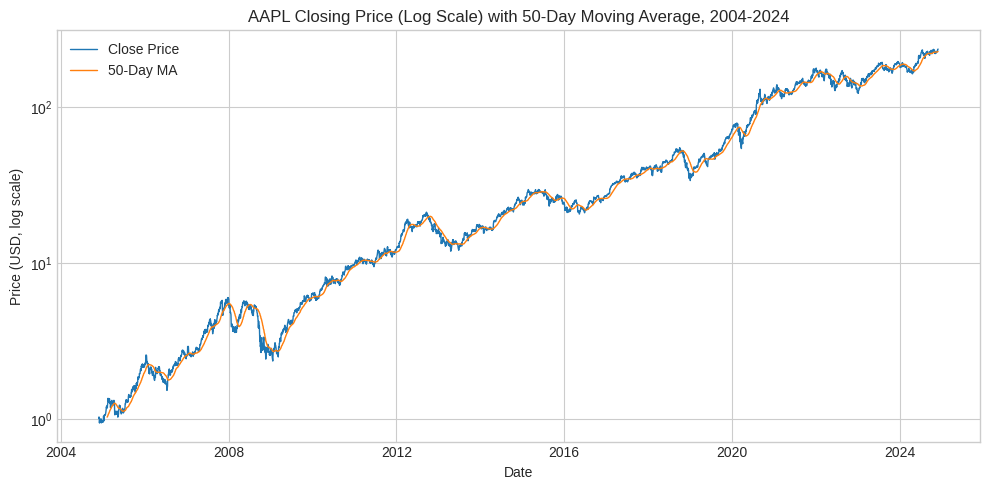

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["Date"], df["Close"], label="Close Price", linewidth=1)
ax.plot(df["Date"], df["MA_50"], label="50-Day MA", linewidth=1)
ax.set_yscale("log")
ax.set_title("AAPL Closing Price (Log Scale) with 50-Day Moving Average, 2004-2024")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD, log scale)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
fig.tight_layout()
plt.show()

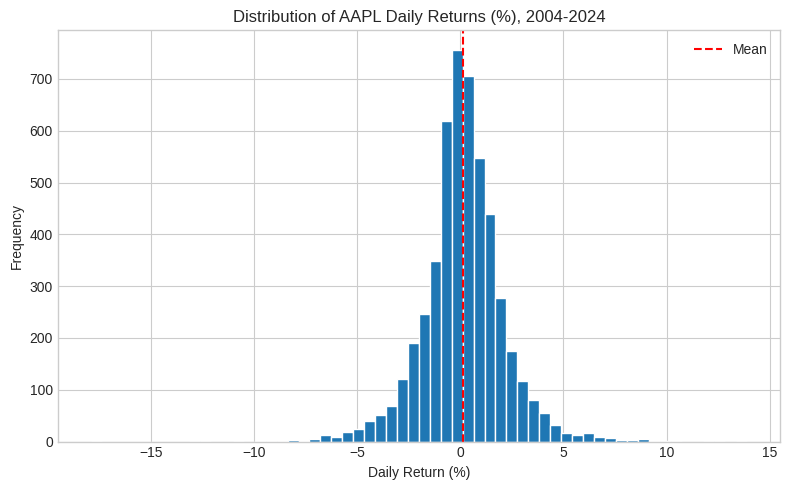

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Daily_Return_%"].dropna(), bins=60, edgecolor="white")
ax.axvline(df["Daily_Return_%"].mean(), color="red", linestyle="--", label="Mean")
ax.set_title("Distribution of AAPL Daily Returns (%), 2004-2024")
ax.set_xlabel("Daily Return (%)"); ax.set_ylabel("Frequency")
ax.legend()
fig.tight_layout()
plt.show()

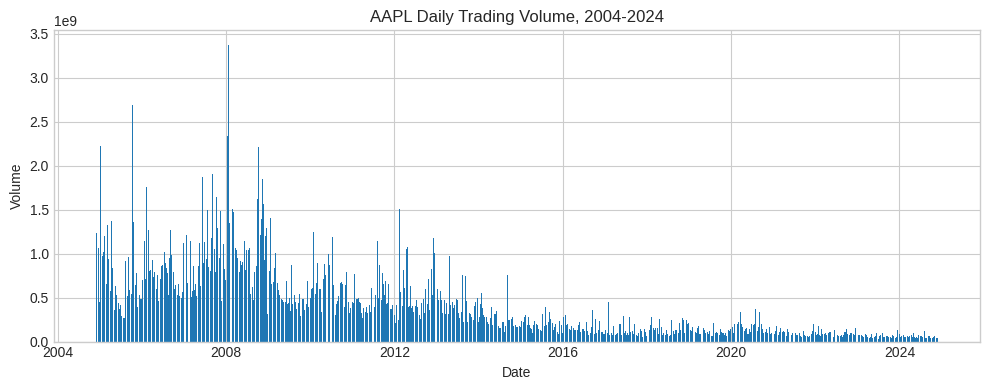

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df["Date"], df["Volume"], width=1.5)
ax.set_title("AAPL Daily Trading Volume, 2004-2024")
ax.set_xlabel("Date"); ax.set_ylabel("Volume")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()